# 【解答編】2026年9月11日 2026機械学習PJ 第2回 深層学習の概要 演習ノートブック

本ノートブックでは，演習を通して以下の内容を理解することを目的とする:

1. PyTorchを用いた深層学習モデルの構築が，どのような順序で行われるのか
2. `loss.backward()`や`optimizer.step()`など，学習ループの主要な処理が何をしているのか
3. 学習率などのハイパーパラメータを変更すると，学習結果がどのように変化するのか
4. 評価データとテストデータを，どのように使い分けるべきか
5. 深層学習が常に従来の機械学習より高精度になるとは限らないこと

作成者: 坪井 一馬 (本資料は生成AIを使用して作成した部分がありますが，最終的な責任は坪井に帰属します)

## 0. 共通準備

このノートブックの実行にあたって，必ず最初に実行しておくこと．途中で「ランタイムが切断」されるなどあれば，再度実行すること．

### 0.1. モジュールのインポートなど

必要となるPythonの機能を使えるようにする．

⭐️**重要**⭐️ **最初にGoogle Colabの設定において「T4 GPU」を使用する設定にしてください．画面右上にある「▼」から選択できます．**

In [1]:
# Python標準ライブラリ
from pathlib import Path
import copy
import random

# 数値計算・表形式データ・可視化
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# scikit-learn
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# PyTorch
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

In [2]:
# 実行ごとのばらつきを小さくするため，乱数を固定する
RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

# GPUが使える場合はGPU，使えない場合はCPUを使用する
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("使用するデバイス:", device)

使用するデバイス: cuda


### 0.2. Titanicデータセットの読み込み

Titanicデータセットでは，乗客の情報から，

```text
0：死亡
1：生存
```

を予測する2値分類を行う．

In [3]:
TITANIC_URL = (
    "https://raw.githubusercontent.com/"
    "datasciencedojo/datasets/master/titanic.csv"
)

# ColabなどではURLから読み込む．
# オフラインの場合は，同じフォルダのtitanic.csvを利用する．
try:
    df = pd.read_csv(TITANIC_URL)
    print("Titanicデータをオンラインから読み込みました．")
except Exception:
    local_candidates = [
        Path("titanic.csv"),
        Path("/mnt/data/titanic.csv"),
    ]

    for local_path in local_candidates:
        if local_path.exists():
            df = pd.read_csv(local_path)
            print(
                "Titanicデータをローカルファイルから読み込みました:",
                local_path,
            )
            break
    else:
        raise FileNotFoundError(
            "Titanicデータを取得できませんでした．"
            "titanic.csvをNotebookと同じフォルダに置いてください．"
        )

print("データ数:", len(df))
print("列数:", len(df.columns))

display(df.head())

Titanicデータをオンラインから読み込みました．
データ数: 891
列数: 12


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### 0.3. データの分割と前処理

演習では深層学習の実装を中心に扱うため，データの分割と前処理はあらかじめ用意してある．

前回と同様に，訓練データ60%，評価データ20%，テストデータ20%へ分割する．

In [4]:
# 今回使用する特徴量
feature_columns = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked",
]

X = df[feature_columns].copy()
y = df["Survived"].copy()

# 全体を訓練60%と一時データ40%へ分割する
(
    X_train,
    X_temp,
    y_train,
    y_temp,
) = train_test_split(
    X,
    y,
    test_size=0.4,
    random_state=RANDOM_STATE,
    stratify=y,
)

# 一時データ40%を，評価20%とテスト20%へ分割する
(
    X_val,
    X_test,
    y_val,
    y_test,
) = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=RANDOM_STATE,
    stratify=y_temp,
)

print("訓練データ:", X_train.shape)
print("評価データ:", X_val.shape)
print("テストデータ:", X_test.shape)

訓練データ: (534, 7)
評価データ: (178, 7)
テストデータ: (179, 7)


In [5]:
numeric_features = [
    "Age",
    "SibSp",
    "Parch",
    "Fare",
]

categorical_features = [
    "Pclass",
    "Sex",
    "Embarked",
]

# 数値特徴量は欠損値を中央値で補完し，標準化する
numeric_transformer = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median"),
    ),
    (
        "scaler",
        StandardScaler(),
    ),
])

# scikit-learnのバージョン差を吸収する
try:
    one_hot_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False,
    )
except TypeError:
    one_hot_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse=False,
    )

# カテゴリ特徴量は欠損値を最頻値で補完し，One-Hot Encodingする
categorical_transformer = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent"),
    ),
    (
        "onehot",
        one_hot_encoder,
    ),
])

preprocessor = ColumnTransformer([
    (
        "numeric",
        numeric_transformer,
        numeric_features,
    ),
    (
        "categorical",
        categorical_transformer,
        categorical_features,
    ),
])

# 前処理の基準は訓練データだけから学習する
X_train_processed = preprocessor.fit_transform(
    X_train
).astype(np.float32)

# 評価・テストデータには，同じ変換を適用するだけにする
X_val_processed = preprocessor.transform(
    X_val
).astype(np.float32)

X_test_processed = preprocessor.transform(
    X_test
).astype(np.float32)

processed_feature_names = (
    preprocessor.get_feature_names_out()
)

print("前処理後の特徴量数:", len(processed_feature_names))
print("訓練データ:", X_train_processed.shape)
print("評価データ:", X_val_processed.shape)
print("テストデータ:", X_test_processed.shape)

前処理後の特徴量数: 12
訓練データ: (534, 12)
評価データ: (178, 12)
テストデータ: (179, 12)


## 演習1. PyTorchによる深層学習モデルの構築

以下の「パーツA〜F」を正しく**並び替えて**，評価データまで使ったモデル学習の枠組みを完成させよ．

ただし，以下の点に注意すること:

- パーツ自体を変更する必要はありません．
- 前回から繰り返し扱っている，(1)データの準備，(2)モデルの準備，(3)学習，(4)テスト・推論の流れを思い出すこと．
- 今回の演習1では，まだテストデータによる最終評価は行いません．
- 事前に定義していない変数を使うことはできません．
- コード自体の意味が完全にわからなくても，コメントを手がかりに，そのコードが何をしているかを考えること．

### パーツ

セル単位で配置すること．

#### A

```python
# モデル，損失関数，Optimizerを用意する
ex1_model = TitanicNet(
    input_dim=X_train_processed.shape[1],
    hidden_dim_1=32,
    hidden_dim_2=16,
    dropout_rate=0.1,
).to(device)

ex1_loss_function = nn.BCEWithLogitsLoss()

ex1_optimizer = torch.optim.Adam(
    ex1_model.parameters(),
    lr=0.001,
)
```

#### B

```python
# 複数Epochにわたって学習し，評価Lossが最小のモデルを保存する
ex1_best_val_loss = float("inf")
ex1_best_epoch = None
ex1_best_state = None

ex1_train_loss_history = []
ex1_val_loss_history = []

for epoch in range(60):
    ex1_model.train()

    total_loss = 0.0
    total_count = 0

    for features, labels in ex1_train_loader:
        features = features.to(device)
        labels = labels.to(device)

        ex1_optimizer.zero_grad()

        outputs = ex1_model(features)

        loss = ex1_loss_function(
            outputs,
            labels,
        )

        loss.backward()
        ex1_optimizer.step()

        total_loss += (
            loss.item()
            * features.size(0)
        )

        total_count += labels.size(0)

    train_loss = total_loss / total_count

    val_result = evaluate_model(
        ex1_model,
        ex1_val_loader,
        ex1_loss_function,
        device,
    )

    ex1_train_loss_history.append(
        train_loss
    )

    ex1_val_loss_history.append(
        val_result["loss"]
    )

    if val_result["loss"] < ex1_best_val_loss:
        ex1_best_val_loss = val_result["loss"]
        ex1_best_epoch = epoch + 1

        ex1_best_state = copy.deepcopy(
            ex1_model.state_dict()
        )
```

#### C

```python
def evaluate_model(
    model,
    data_loader,
    loss_function,
    device,
    threshold=0.5,
):
    # 評価モードへ切り替える
    model.eval()

    total_loss = 0.0
    total_count = 0

    probabilities_all = []
    predictions_all = []
    labels_all = []

    # 評価時には勾配を計算しない
    with torch.no_grad():
        for features, labels in data_loader:
            features = features.to(device)
            labels = labels.to(device)

            logits = model(features)

            loss = loss_function(
                logits,
                labels,
            )

            probabilities = torch.sigmoid(
                logits
            )

            predictions = (
                probabilities >= threshold
            ).float()

            total_loss += (
                loss.item()
                * features.size(0)
            )

            total_count += features.size(0)

            probabilities_all.extend(
                probabilities
                .cpu()
                .numpy()
                .reshape(-1)
            )

            predictions_all.extend(
                predictions
                .cpu()
                .numpy()
                .reshape(-1)
            )

            labels_all.extend(
                labels
                .cpu()
                .numpy()
                .reshape(-1)
            )

    return {
        "loss": total_loss / total_count,
        "accuracy": accuracy_score(
            labels_all,
            predictions_all,
        ),
        "probabilities": np.array(
            probabilities_all
        ),
        "predictions": np.array(
            predictions_all
        ).astype(int),
        "labels": np.array(
            labels_all
        ).astype(int),
    }
```

#### D

```python
# Tensorへ変換し，DatasetとDataLoaderを作る
ex1_train_dataset = TensorDataset(
    torch.tensor(
        X_train_processed,
        dtype=torch.float32,
    ),
    torch.tensor(
        y_train.to_numpy(),
        dtype=torch.float32,
    ).reshape(-1, 1),
)

ex1_val_dataset = TensorDataset(
    torch.tensor(
        X_val_processed,
        dtype=torch.float32,
    ),
    torch.tensor(
        y_val.to_numpy(),
        dtype=torch.float32,
    ).reshape(-1, 1),
)

ex1_test_dataset = TensorDataset(
    torch.tensor(
        X_test_processed,
        dtype=torch.float32,
    ),
    torch.tensor(
        y_test.to_numpy(),
        dtype=torch.float32,
    ).reshape(-1, 1),
)

ex1_train_loader = DataLoader(
    ex1_train_dataset,
    batch_size=32,
    shuffle=True,
)

ex1_val_loader = DataLoader(
    ex1_val_dataset,
    batch_size=64,
    shuffle=False,
)

ex1_test_loader = DataLoader(
    ex1_test_dataset,
    batch_size=64,
    shuffle=False,
)
```

#### E

```python
# 評価データで最も良かった時点のモデルを復元する
ex1_model.load_state_dict(
    ex1_best_state
)

print(
    "評価Lossが最小だったEpoch:",
    ex1_best_epoch,
)

print(
    f"最小の評価Loss: "
    f"{ex1_best_val_loss:.4f}"
)
```

#### F

```python
class TitanicNet(nn.Module):
    def __init__(
        self,
        input_dim,
        hidden_dim_1=32,
        hidden_dim_2=16,
        dropout_rate=0.1,
    ):
        super().__init__()

        self.network = nn.Sequential(
            # 入力を32個の内部表現へ変換する
            nn.Linear(
                input_dim,
                hidden_dim_1,
            ),
            nn.ReLU(),

            # 学習中だけ一部の値をランダムに0にする
            nn.Dropout(dropout_rate),

            # 32個の内部表現を16個へ変換する
            nn.Linear(
                hidden_dim_1,
                hidden_dim_2,
            ),
            nn.ReLU(),

            # 最後に生存側への傾きを表す1個のスコアを出力する
            nn.Linear(
                hidden_dim_2,
                1,
            ),
        )

    def forward(self, x):
        return self.network(x)
```

### 回答

#### (1) データの準備

まず，PyTorchで扱えるTensor，Dataset，DataLoaderを用意する．

In [6]:
# Tensorへ変換し，DatasetとDataLoaderを作る
ex1_train_dataset = TensorDataset(
    torch.tensor(
        X_train_processed,
        dtype=torch.float32,
    ),
    torch.tensor(
        y_train.to_numpy(),
        dtype=torch.float32,
    ).reshape(-1, 1),
)

ex1_val_dataset = TensorDataset(
    torch.tensor(
        X_val_processed,
        dtype=torch.float32,
    ),
    torch.tensor(
        y_val.to_numpy(),
        dtype=torch.float32,
    ).reshape(-1, 1),
)

ex1_test_dataset = TensorDataset(
    torch.tensor(
        X_test_processed,
        dtype=torch.float32,
    ),
    torch.tensor(
        y_test.to_numpy(),
        dtype=torch.float32,
    ).reshape(-1, 1),
)

ex1_train_loader = DataLoader(
    ex1_train_dataset,
    batch_size=32,
    shuffle=True,
)

ex1_val_loader = DataLoader(
    ex1_val_dataset,
    batch_size=64,
    shuffle=False,
)

ex1_test_loader = DataLoader(
    ex1_test_dataset,
    batch_size=64,
    shuffle=False,
)

#### (2) モデルの準備

モデルの設計図となるクラスを用意し，その後にモデル，損失関数，Optimizerを用意する．

In [7]:
class TitanicNet(nn.Module):
    def __init__(
        self,
        input_dim,
        hidden_dim_1=32,
        hidden_dim_2=16,
        dropout_rate=0.1,
    ):
        super().__init__()

        self.network = nn.Sequential(
            # 入力を32個の内部表現へ変換する
            nn.Linear(
                input_dim,
                hidden_dim_1,
            ),
            nn.ReLU(),

            # 学習中だけ一部の値をランダムに0にする
            nn.Dropout(dropout_rate),

            # 32個の内部表現を16個へ変換する
            nn.Linear(
                hidden_dim_1,
                hidden_dim_2,
            ),
            nn.ReLU(),

            # 最後に生存側への傾きを表す1個のスコアを出力する
            nn.Linear(
                hidden_dim_2,
                1,
            ),
        )

    def forward(self, x):
        return self.network(x)

In [8]:
# モデル，損失関数，Optimizerを用意する
ex1_model = TitanicNet(
    input_dim=X_train_processed.shape[1],
    hidden_dim_1=32,
    hidden_dim_2=16,
    dropout_rate=0.1,
).to(device)

ex1_loss_function = nn.BCEWithLogitsLoss()

ex1_optimizer = torch.optim.Adam(
    ex1_model.parameters(),
    lr=0.001,
)

#### (3) 学習・評価

評価用の関数を用意した後，訓練データで学習し，評価データでモデルを確認する．最後に，評価データで最も良かった時点のモデルを復元する．

In [9]:
def evaluate_model(
    model,
    data_loader,
    loss_function,
    device,
    threshold=0.5,
):
    # 評価モードへ切り替える
    model.eval()

    total_loss = 0.0
    total_count = 0

    probabilities_all = []
    predictions_all = []
    labels_all = []

    # 評価時には勾配を計算しない
    with torch.no_grad():
        for features, labels in data_loader:
            features = features.to(device)
            labels = labels.to(device)

            logits = model(features)

            loss = loss_function(
                logits,
                labels,
            )

            probabilities = torch.sigmoid(
                logits
            )

            predictions = (
                probabilities >= threshold
            ).float()

            total_loss += (
                loss.item()
                * features.size(0)
            )

            total_count += features.size(0)

            probabilities_all.extend(
                probabilities
                .cpu()
                .numpy()
                .reshape(-1)
            )

            predictions_all.extend(
                predictions
                .cpu()
                .numpy()
                .reshape(-1)
            )

            labels_all.extend(
                labels
                .cpu()
                .numpy()
                .reshape(-1)
            )

    return {
        "loss": total_loss / total_count,
        "accuracy": accuracy_score(
            labels_all,
            predictions_all,
        ),
        "probabilities": np.array(
            probabilities_all
        ),
        "predictions": np.array(
            predictions_all
        ).astype(int),
        "labels": np.array(
            labels_all
        ).astype(int),
    }

In [10]:
# 複数Epochにわたって学習し，評価Lossが最小のモデルを保存する
ex1_best_val_loss = float("inf")
ex1_best_epoch = None
ex1_best_state = None

ex1_train_loss_history = []
ex1_val_loss_history = []

for epoch in range(60):
    ex1_model.train()

    total_loss = 0.0
    total_count = 0

    for features, labels in ex1_train_loader:
        features = features.to(device)
        labels = labels.to(device)

        ex1_optimizer.zero_grad()

        outputs = ex1_model(features)

        loss = ex1_loss_function(
            outputs,
            labels,
        )

        loss.backward()
        ex1_optimizer.step()

        total_loss += (
            loss.item()
            * features.size(0)
        )

        total_count += labels.size(0)

    train_loss = total_loss / total_count

    val_result = evaluate_model(
        ex1_model,
        ex1_val_loader,
        ex1_loss_function,
        device,
    )

    ex1_train_loss_history.append(
        train_loss
    )

    ex1_val_loss_history.append(
        val_result["loss"]
    )

    if val_result["loss"] < ex1_best_val_loss:
        ex1_best_val_loss = val_result["loss"]
        ex1_best_epoch = epoch + 1

        ex1_best_state = copy.deepcopy(
            ex1_model.state_dict()
        )

In [11]:
# 評価データで最も良かった時点のモデルを復元する
ex1_model.load_state_dict(
    ex1_best_state
)

print(
    "評価Lossが最小だったEpoch:",
    ex1_best_epoch,
)

print(
    f"最小の評価Loss: "
    f"{ex1_best_val_loss:.4f}"
)

評価Lossが最小だったEpoch: 32
最小の評価Loss: 0.3978


### 演習1.2. 学習ループの主要処理

演習1で並び替えたコードの中には，次の5つの処理が含まれている．

```python
optimizer.zero_grad()
outputs = model(features)
loss = loss_function(outputs, labels)
loss.backward()
optimizer.step()
```

それぞれが何を行っているか，1行ずつ説明せよ．

**【模範解答】**

1. `optimizer.zero_grad()`：前回までに保存されている勾配(損失関数を更新するためのもの)をリセットする．
2. `outputs = model(features)`：現在のモデルへ入力を与えて，予測値であるlogitを得る．
3. `loss = loss_function(outputs, labels)`：損失関数に基づいて，予測と正解のずれを損失として計算する．
4. `loss.backward()`：損失を小さくするために，各パラメータをどちらへどの程度動かせばよいかを勾配として計算する．
5. `optimizer.step()`：計算された勾配を用いて，実際にモデルのパラメータを更新する．

## 演習2. 学習率を変更することによる影響を考察する

深層学習では，学習率`lr`が重要なハイパーパラメータの1つである．

学習率は，1回のパラメータ更新でどの程度値を動かすかに関係する．

一般に，

- 学習率が小さすぎる場合：学習がなかなか進まないことがある．
- 学習率が大きすぎる場合：良い値の周辺を飛び越えて，学習が不安定になることがある．

ここでは，複数の学習率を同じ条件で比較し，評価データへの性能がどのように変化するか確認する．

In [12]:
def train_candidate(
    learning_rate,
    max_epochs=50,
):
    # 比較条件をそろえるため，候補ごとに乱数を同じ値へ戻す
    random.seed(RANDOM_STATE)
    np.random.seed(RANDOM_STATE)
    torch.manual_seed(RANDOM_STATE)

    candidate_model = TitanicNet(
        input_dim=X_train_processed.shape[1],
        hidden_dim_1=32,
        hidden_dim_2=16,
        dropout_rate=0.1,
    ).to(device)

    candidate_loss_function = (
        nn.BCEWithLogitsLoss()
    )

    candidate_optimizer = (
        torch.optim.Adam(
            candidate_model.parameters(),
            lr=learning_rate,
        )
    )

    # ミニバッチの並び順も比較しやすいように固定する
    generator = torch.Generator()
    generator.manual_seed(RANDOM_STATE)

    candidate_train_loader = DataLoader(
        ex1_train_dataset,
        batch_size=32,
        shuffle=True,
        generator=generator,
    )

    best_val_loss = float("inf")
    best_val_accuracy = None
    best_epoch = None
    best_state = None

    for epoch in range(max_epochs):
        candidate_model.train()

        for features, labels in candidate_train_loader:
            features = features.to(device)
            labels = labels.to(device)

            candidate_optimizer.zero_grad()

            outputs = candidate_model(
                features
            )

            loss = candidate_loss_function(
                outputs,
                labels,
            )

            loss.backward()
            candidate_optimizer.step()

        val_result = evaluate_model(
            candidate_model,
            ex1_val_loader,
            candidate_loss_function,
            device,
        )

        if val_result["loss"] < best_val_loss:
            best_val_loss = val_result["loss"]
            best_val_accuracy = val_result["accuracy"]
            best_epoch = epoch + 1

            best_state = copy.deepcopy(
                candidate_model.state_dict()
            )

    return {
        "learning_rate": learning_rate,
        "best_val_loss": best_val_loss,
        "best_val_accuracy": best_val_accuracy,
        "best_epoch": best_epoch,
        "best_state": best_state,
    }

In [13]:
candidate_learning_rates = [
    0.0001,
    0.001,
    0.01,
    0.1,
]

learning_rate_results = []
candidate_states = {}

for learning_rate in candidate_learning_rates:
    result = train_candidate(
        learning_rate=learning_rate,
        max_epochs=50,
    )

    candidate_states[
        learning_rate
    ] = result["best_state"]

    learning_rate_results.append({
        "learning_rate": result["learning_rate"],
        "best_val_loss": result["best_val_loss"],
        "best_val_accuracy": result["best_val_accuracy"],
        "best_epoch": result["best_epoch"],
    })

learning_rate_results_df = pd.DataFrame(
    learning_rate_results
)

display(learning_rate_results_df)

,learning_rate,best_val_loss,best_val_accuracy,best_epoch
0,0.0001,0.558538,0.691011,50
1,0.0010,0.398370,0.853933,34
2,0.0100,0.399138,0.825843,11
3,0.1000,0.406242,0.831461,13


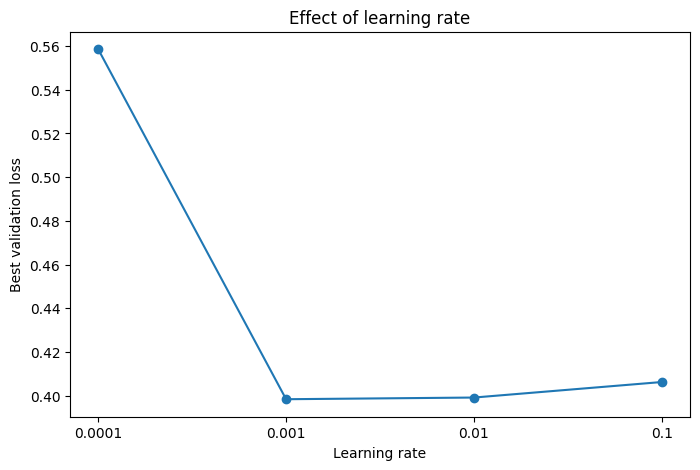

In [14]:
x_positions = np.arange(
    len(learning_rate_results_df)
)

plt.figure(figsize=(8, 5))

plt.plot(
    x_positions,
    learning_rate_results_df[
        "best_val_loss"
    ],
    marker="o",
)

plt.xticks(
    x_positions,
    learning_rate_results_df[
        "learning_rate"
    ].astype(str),
)

plt.xlabel("Learning rate")
plt.ylabel("Best validation loss")
plt.title("Effect of learning rate")
plt.show()

### 演習2.1. 結果から考察する

上の結果から，次の点を考察せよ．

1. 指定した候補の中で，評価Lossが最も小さかった学習率はいくつか．
2. 学習率が小さすぎる場合，どのような結果になったか．
3. 学習率が大きくなれば，必ず評価性能が良くなると言えるか．
4. 学習率を選ぶためにテストデータを使わず，評価データを使うのはなぜか．

**【模範解答例】**

1. 実行結果では，候補の中で評価Lossが最も小さい学習率を選ぶ．乱数や実行環境によって細かな値は変化しうる．
2. 小さすぎる学習率では，限られたEpoch数の中で十分にパラメータが更新されず，学習不足になりやすい．
3. 学習率を大きくすれば必ず性能が向上するわけではない．大きすぎると，損失が小さくなる領域を飛び越えて学習が不安定になることがある．
4. テストデータを見ながら学習率を選ぶと，テストデータに都合の良い設定を選んだことになり，未知データに対する最終評価としての意味が弱くなるためである．

### 演習2.2. 評価データに基づいて学習率を選ぶ

`learning_rate_results_df`から，評価Lossが最小の行を選び，その学習率を`best_learning_rate`へ保存せよ．

以下の`# [WRITE ME n]`を埋めること．

In [15]:
# 評価Lossが最小の行番号を取得する
best_lr_index = (
    learning_rate_results_df[
        "best_val_loss"
    ].idxmin()
)

# 最良の学習率を取り出す
best_learning_rate = float(
    learning_rate_results_df.loc[
        best_lr_index,
        "learning_rate",
    ]
)

# そのときの最良Epochも取り出す
best_lr_epoch = int(
    learning_rate_results_df.loc[
        best_lr_index,
        "best_epoch",
    ]
)

print(
    "評価データで選ばれた学習率:",
    best_learning_rate,
)

print(
    "その学習率で評価Lossが最小だったEpoch:",
    best_lr_epoch,
)

評価データで選ばれた学習率: 0.001
その学習率で評価Lossが最小だったEpoch: 34


## 演習3. 学習処理の主要5ステップを自分で書く

演習1では，学習コード全体を並び替えた．

ここでは，最も重要なミニバッチ1回分の処理を，自分で記述する．

以下の`# [WRITE ME n]`を，説明編や演習1を参考にして埋めよ．

使用する処理は次の5つである．

```text
勾配をリセット
→ 予測
→ 損失計算
→ 逆伝播
→ パラメータ更新
```

In [16]:
practice_model = TitanicNet(
    input_dim=X_train_processed.shape[1],
    hidden_dim_1=32,
    hidden_dim_2=16,
    dropout_rate=0.1,
).to(device)

practice_loss_function = (
    nn.BCEWithLogitsLoss()
)

practice_optimizer = torch.optim.Adam(
    practice_model.parameters(),
    lr=best_learning_rate,
)

In [17]:
practice_loss_history = []

for epoch in range(20):
    practice_model.train()

    total_loss = 0.0
    total_count = 0

    for features, labels in ex1_train_loader:
        features = features.to(device)
        labels = labels.to(device)

        # 1. 前回の勾配をリセットする
        practice_optimizer.zero_grad()

        # 2. 現在のモデルで予測する
        outputs = practice_model(features)

        # 3. 予測と正解のずれを計算する
        loss = practice_loss_function(
            outputs,
            labels,
        )

        # 4. 損失を小さくする修正方向を計算する
        loss.backward()

        # 5. 実際にパラメータを更新する
        practice_optimizer.step()

        total_loss += (
            loss.item()
            * features.size(0)
        )

        total_count += labels.size(0)

    practice_loss_history.append(
        total_loss / total_count
    )

print(
    "20 Epoch後の訓練Loss:",
    practice_loss_history[-1],
)

20 Epoch後の訓練Loss: 0.4314419319120686


In [18]:
practice_val_result = evaluate_model(
    practice_model,
    ex1_val_loader,
    practice_loss_function,
    device,
)

print(
    f"評価Loss: "
    f"{practice_val_result['loss']:.4f}"
)

print(
    f"評価Accuracy: "
    f"{practice_val_result['accuracy']:.3f}"
)

評価Loss: 0.4060
評価Accuracy: 0.848


## 演習4. テストデータによる最終評価とロジスティック回帰との比較

ここまで，モデルや学習率の選択には評価データを使ってきた．

最後に，演習2で選ばれた学習率に対応する最良モデルを復元し，テストデータで一度だけ性能を確認する．

その後，同じ前処理済みデータへロジスティック回帰を適用し，結果を比較する．

In [19]:
selected_model = TitanicNet(
    input_dim=X_train_processed.shape[1],
    hidden_dim_1=32,
    hidden_dim_2=16,
    dropout_rate=0.1,
).to(device)

selected_model.load_state_dict(
    candidate_states[
        best_learning_rate
    ]
)

selected_loss_function = (
    nn.BCEWithLogitsLoss()
)

selected_test_result = evaluate_model(
    selected_model,
    ex1_test_loader,
    selected_loss_function,
    device,
)

print(
    f"Neural Networkのテスト精度: "
    f"{selected_test_result['accuracy']:.3f}"
)

Neural Networkのテスト精度: 0.816


,Model,Test Accuracy
0,Logistic Regression,0.804469
1,Neural Network,0.815642


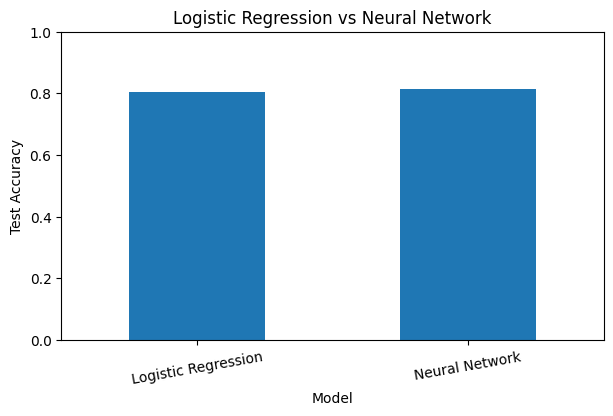

In [20]:
logistic_model = LogisticRegression(
    max_iter=2000,
    random_state=RANDOM_STATE,
)

logistic_model.fit(
    X_train_processed,
    y_train,
)

logistic_test_predictions = (
    logistic_model.predict(
        X_test_processed
    )
)

logistic_test_accuracy = accuracy_score(
    y_test,
    logistic_test_predictions,
)

comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Neural Network",
    ],
    "Test Accuracy": [
        logistic_test_accuracy,
        selected_test_result["accuracy"],
    ],
})

display(comparison_df)

comparison_df.plot(
    x="Model",
    y="Test Accuracy",
    kind="bar",
    legend=False,
    figsize=(7, 4),
)

plt.ylim(0.0, 1.0)
plt.ylabel("Test Accuracy")
plt.title(
    "Logistic Regression vs Neural Network"
)
plt.xticks(rotation=10)
plt.show()

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 27515 (\N{CJK UNIFIED IDEOGRAPH-6B7B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 20129 (\N{CJK UNIFIED IDEOGRAPH-4EA1}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 29983 (\N{CJK UNIFIED IDEOGRAPH-751F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 23384 (\N{CJK UNIFIED IDEOGRAPH-5B58}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


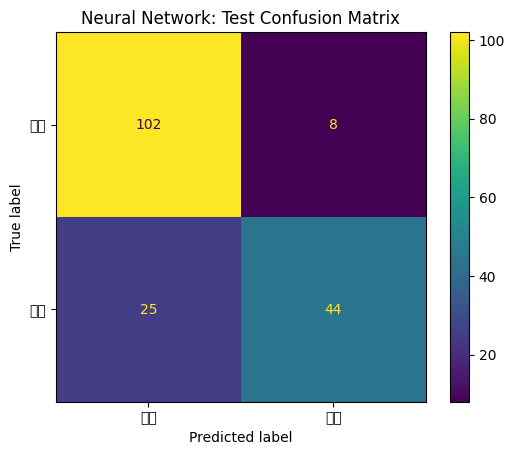

In [21]:
selected_cm = confusion_matrix(
    selected_test_result["labels"],
    selected_test_result["predictions"],
)

selected_display = ConfusionMatrixDisplay(
    confusion_matrix=selected_cm,
    display_labels=[
        "死亡",
        "生存",
    ],
)

selected_display.plot()
plt.title(
    "Neural Network: Test Confusion Matrix"
)
plt.show()

### 演習4.1. 比較結果からの考察

ロジスティック回帰による分類と，深層学習のモデルに基づく分類を比較し，どちらの精度が高かったかを確認せよ．

また，深層学習のモデルに基づく分類の精度がより高かったとしても，「ロジスティック回帰に比べて深層学習が絶対的に優れている」と断定できない理由を説明せよ．

**【模範解答例】**

今回の実行では，両者の精度は近い値となり，設定によってはニューラルネットワークが少し高い場合も，ロジスティック回帰が高い場合もありうる．

しかし，この結果だけから深層学習が絶対的に優れているとは言えない．モデルの性能は，前処理，使用した特徴量，学習率，モデルの層数やユニット数，乱数，データ分割など，多くの条件に依存する．

また，Titanicはデータ数が比較的小さく，表形式で意味の分かりやすい特徴量が用意されているため，ロジスティック回帰のような比較的単純なモデルでも十分に高い性能を得られることがある．